In [19]:
#K-means
import pandas as pd
import matplotlib.pyplot as plt
dataset=pd.read_csv('data/KMeansData.csv') #data만 작성 시 상위 폴더 python 바로 아래에 있는 KMeanData를 가지고 옴

# dataset.shape

In [20]:
#K-means는 답이 없으므로, y(종속변수)를 추출할 필요가 없음
X=dataset.iloc[:,:].values
X[:,0] #시간만 가져옴
X[:,1] #점수만 가져옴

array([ 73.,  55.,  55.,  89.,  79.,  26.,  15.,  62.,  59.,  74.,  78.,
        46.,   5.,  38.,  49.,  66.,  29.,  74.,  34.,  71.,   9.,  67.,
        43.,   0.,  90.,  77.,  47.,  50.,  38.,  23.,  31.,   2.,  20.,
        80.,  70.,  75.,  26.,  74.,  78.,  76.,  42.,  25.,  85.,  47.,
        36.,  69.,  22.,  74.,  23.,  35.,  94.,  75.,  16.,  27.,  62.,
        83.,  61.,  96.,  51.,  29.,  20.,  89.,  76.,  82.,  76.,  27.,
        15.,  80.,  22.,  78.,  52.,  75.,  74.,  75.,  39.,  43.,  57.,
        59.,  91., 100.,  19.,  80.,  25.,  38.,  79.,  77.,  30.,  14.,
        79.,  52.,  68.,  37.,  78.,  86.,  24.,  56.,  84.,  87.,  13.,
        30.])

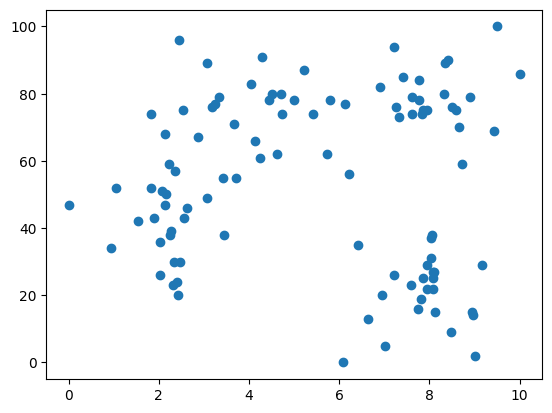

In [21]:
#시각화 작업 수행
plt.scatter(X[:,0],X[:,1])
plt.show()
# X축과 Y축의 단위가 다름 So 시각적 편하지만, 왜곡 가능성 O

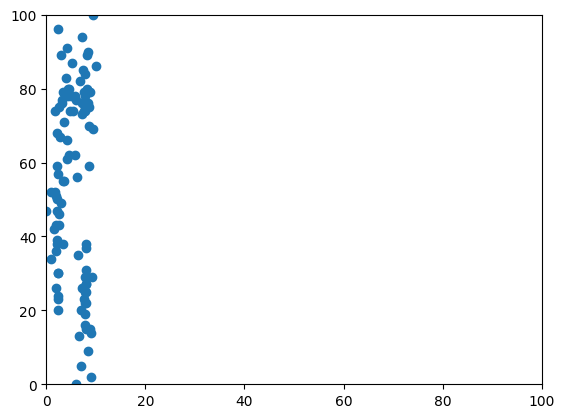

In [22]:
#시각화 작업 수행
plt.scatter(X[:,0],X[:,1])
plt.xlim(0,100)
plt.ylim(0,100)
plt.show()


In [23]:
# StandarScaler를 통해 단위 차이를 크지 않게 규모를 바꿔줌
from sklearn.preprocessing import StandardScaler #라이브러리 불러오기
scaler=StandardScaler() #모델 생성
X_trans=scaler.fit_transform(X) #모델에 데이터 적용
X_trans[:5], X[:5] #출력(테스트용)

(array([[ 0.68729921,  0.73538376],
        [-0.66687438,  0.04198891],
        [-0.77161709,  0.04198891],
        [-0.9100271 ,  1.35173473],
        [-0.8090252 ,  0.96651537]]),
 array([[ 7.33, 73.  ],
        [ 3.71, 55.  ],
        [ 3.43, 55.  ],
        [ 3.06, 89.  ],
        [ 3.33, 79.  ]]))

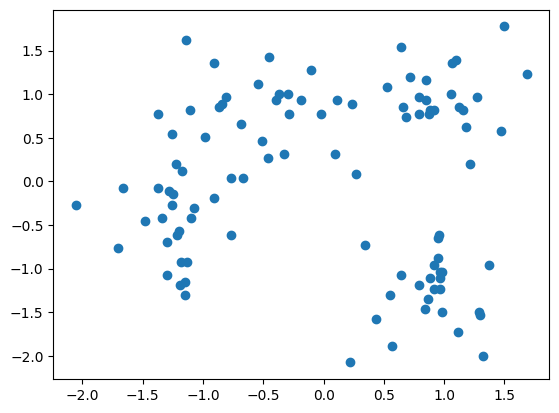

In [24]:
#StandScale을 통해 -2.0 ~1.5 범위 사이가 됨
plt.scatter(X_trans[:,0],X_trans[:,1])
plt.show()

In [25]:
#데이터 거리 제곱의 합을 구함(1일때, 2일때 3일때...)
from sklearn.cluster import KMeans #데이터의 거리의 제곱의 합을 구하는 라이브러리(k-means X 아님)
inertia_list=[] # 각 점들에서 중심점까지의 거리들의 합 리스트(중심점 - 각 점 거리 합) # inertia=각 중심점거리의 합
for i in range(1,11,1):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=0)
    kmeans.fit(X_trans)
    inertia_list.append(kmeans.inertia_)

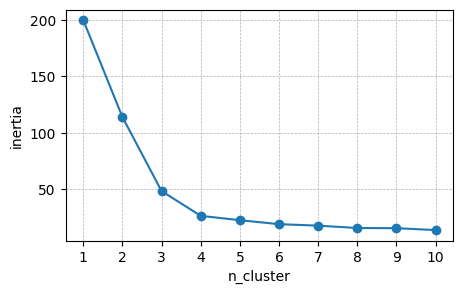

In [26]:
x=range(1,11,1) #배열로 1-10까지 들어감
y=inertia_list
plt.figure(figsize=(5,3))
plt.plot(x,y,marker='o') # X와 Y의 리스트가 같아야 함
plt.xticks([x for x in range(1,11,1)])
plt.grid(True,ls='--',lw=0.5)
plt.xlabel('n_cluster')
plt.ylabel('inertia')
plt.show()

In [27]:
K=4
kmeans= KMeans(n_clusters=K,random_state=0)
kmeans.fit(X_trans)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [28]:
y_pred=kmeans.fit_predict(X_trans)
y_pred, X[:5]


(array([1, 0, 3, 0, 0, 2, 2, 0, 1, 0, 0, 3, 2, 3, 3, 0, 2, 1, 3, 0, 2, 0,
        3, 2, 1, 1, 3, 3, 3, 3, 2, 2, 3, 0, 1, 1, 3, 0, 0, 0, 3, 2, 1, 3,
        3, 1, 2, 0, 2, 2, 1, 0, 2, 2, 0, 0, 0, 0, 3, 2, 2, 1, 1, 1, 1, 2,
        2, 0, 2, 1, 3, 1, 1, 1, 3, 3, 3, 3, 0, 1, 2, 1, 2, 2, 1, 0, 3, 2,
        1, 3, 0, 2, 0, 1, 3, 0, 1, 0, 2, 3], dtype=int32),
 array([[ 7.33, 73.  ],
        [ 3.71, 55.  ],
        [ 3.43, 55.  ],
        [ 3.06, 89.  ],
        [ 3.33, 79.  ]]))

In [29]:
dataset['cluster']=y_pred
dataset

,hour,score,cluster
0,7.33,73,1
1,3.71,55,0
2,3.43,55,3
3,3.06,89,0
4,3.33,79,0
...,...,...,...
95,6.21,56,0
96,7.76,84,1
97,5.22,87,0
98,6.65,13,2


In [30]:
import numpy as np
index=np.where(y_pred==1) #y_pred가 0인 것만 뽑아라 = indices
index


(array([ 0,  8, 17, 24, 25, 34, 35, 42, 45, 50, 61, 62, 63, 64, 69, 71, 72,
        73, 79, 81, 84, 88, 93, 96]),)

In [31]:
X[index,1], X[index,0]


(array([[ 73.,  59.,  74.,  90.,  77.,  70.,  75.,  85.,  69.,  94.,  89.,
          76.,  82.,  76.,  78.,  75.,  74.,  75., 100.,  80.,  79.,  79.,
          86.,  84.]]),
 array([[ 7.33,  8.73,  7.61,  8.42,  6.12,  8.66,  7.95,  7.42,  9.43,
          7.21,  8.34,  8.5 ,  6.91,  7.26,  7.76,  8.58,  7.83,  7.85,
          9.5 ,  8.33,  7.61,  8.89, 10.  ,  7.76]]))

0 [[3.71 3.06 3.33 5.74 4.73 5.   4.13 3.67 2.86 4.5  5.43 4.44 3.17 1.83
  2.53 4.61 4.04 4.25 2.44 4.71 4.29 3.24 2.13 5.8  6.21 5.22]] [[55. 89. 79. 62. 74. 78. 66. 71. 67. 80. 74. 78. 76. 74. 75. 62. 83. 61.
  96. 80. 91. 77. 68. 78. 56. 87.]]
1 [[ 7.33  8.73  7.61  8.42  6.12  8.66  7.95  7.42  9.43  7.21  8.34  8.5
   6.91  7.26  7.76  8.58  7.83  7.85  9.5   8.33  7.61  8.89 10.    7.76]] [[ 73.  59.  74.  90.  77.  70.  75.  85.  69.  94.  89.  76.  82.  76.
   78.  75.  74.  75. 100.  80.  79.  79.  86.  84.]]
2 [[7.22 8.12 7.02 9.17 8.47 6.08 8.03 9.02 7.85 7.94 7.6  6.41 7.75 8.08
  7.94 6.96 8.11 8.94 8.08 7.81 8.07 8.06 8.97 8.03 6.65]] [[26. 15.  5. 29.  9.  0. 31.  2. 25. 22. 23. 35. 16. 27. 29. 20. 27. 15.
  22. 19. 25. 38. 14. 37. 13.]]
3 [[3.43 2.63 3.45 3.06 0.94 1.9  0.   2.16 2.24 2.31 2.43 2.03 1.53 2.14
  2.02 2.06 1.05 2.28 2.56 2.35 2.22 2.33 1.83 2.41 2.46]] [[55. 46. 38. 49. 34. 43. 47. 50. 38. 23. 20. 26. 42. 47. 36. 51. 52. 39.
  43. 57. 59. 30. 52. 24. 30.

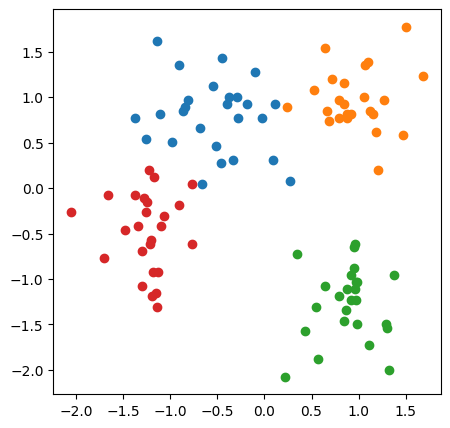

In [32]:
for i in range(K):
    index=np.where(y_pred==i)
    print(i,X[index,0],X[index,1])

flit=dataset['cluster']==0
dataset[flit].index
# centers=kmeans.cluster_centers_


plt.figure(figsize=(5, 5))
for i in range(K):
    index = np.where(y_pred==i)
    x=X_trans[index, 0]
    y=X_trans[index, 1]
    plt.scatter(x, y)
plt.show()

plt.show()

In [ ]:
centers = kmeans.cluster_centers_
import matplotlib.pyplot as plt
import numpy as np
kmeans= KMeans(n_clusters=no,random_state=0)
kmeans, X_org,X_trans,centers_org,c=mol_kmeans(no)
y_pred=kmeans.fit_predict(X_trans)

plt.figure(figsize=(5, 5))
for i in range(K):
    index = np.where(y_pred==i)
    x=X_trans[index, 0]
    y=X_trans[index, 1]
    plt.scatter(x, y, s=100, ec="black")
    plt.title('Score by study time', size=20)
    cx = centers[i, 0]
    cy = centers[i, 1]
    plt.scatter(cx, cy, c='yellow', s=300, ec='black', marker='s')
    plt.text(cx, cy, i, ha='center', va='center')
    plt.xlabel('HOUR')
    plt.ylabel("SCORE")
for idx, x in enumerate(X_trans):
    plt.text(x[0],x[1],idx, ha='center',va='center',color='white', size=5)
plt.show()

ValueError: not enough values to unpack (expected 5, got 4)

In [ ]:
#KMeans 모델 생성
K=4
def model_kmeans():
    from sklearn.cluster import KMeans # 각 중심점 거리의 합을 구하기 위한 라이브러리 불러오기
    import pandas as pd
    kmeans=KMeans(n_clusters=K,random_state=0) #중심점을 K개, 기준은 0으로
    dataset=pd.read_csv('data/KMeansData.csv')
    X=dataset.iloc[:,0:1].values # or X=dataset[:,[0,1]]도 가능한 방법임

    from sklearn.preprocessing import StandardScaler
    scaler=StandardScaler()
    X_trans=scaler.fit_transform(X)
    kmeans.fit(X_trans)

    X_org=scaler.inverse_transform(X_trans)
    centers_org=scaler.inverse_transform(kmeans.cluster_centers_)
    return kmeans, X_org,X_trans,kmeans, centers_org
    


In [ ]:
X_org=scaler.inverse_transform(X_trans)
X_org[5]

array([ 7.22, 26.  ])

In [ ]:
center_org=scaler.inverse_transform(centers)
center_org

array([[ 4.95125   , 74.1875    ],
       [ 8.16869565, 79.2173913 ],
       [ 7.8552    , 20.96      ],
       [ 2.15      , 40.5       ],
       [ 2.84916667, 73.83333333]])

In [ ]:
dataset.loc[31,:]

hour       9.02
score      2.00
cluster    2.00
Name: 31, dtype: float64

In [ ]:
#Kmeans 모델생성
def model_kmeans(K):
    import pandas as pd #데이터 처리를 위해 pandas 라이브러리 호출
    from sklearn.cluster import KMeans # sklearn에서 KMeans 객체 호출
    kmeans=KMeans(n_clusters=K, random_state=0) # 클러스터 개수(n_clusters)를 K개로 설정, random_state로 재현 가능

    dataset=pd.read_csv('data/KMeansData.csv')
    X=dataset.iloc[:,[0,1]].values

    from sklearn.preprocessing import StandardScaler # 데이터 정규화를 위한 StandardScaler를 가져옴
    scaler=StandardScaler() # StandardScaler 객체 생성(평균:0, 표준편차: 1로 설정)
    X_trans=scaler.fit_transform(X) #원본 데이터 X에 대해 표준화 수행 후(평균, 표준편차) X_trans로 정의

    kmeans.fit(X_trans) #표준화된 모델 X_trans를 K-means 모델로 학습

    X_org=scaler.inverse_transform(X_trans) #표준화된 X_trans를 원본으로 되돌림(X_org = X)
    center_org=scaler.inverse_transform(kmeans.cluster_centers_) #K-mean로 찾은 클러스터 중심점, 원래 스케일로 되돌림(center_org 정의)
    return kmeans, X_org, X_trans, center_org #학습된 모델(kmeans) 


In [ ]:
from sklearn.cluster import KMeans
intertia_list=[]
for i in range(1,11,1):
    kmeans,X,X_trans, center_org=model_kmeans()
    kmeans.fit(X_trans)
    intertia_list.append(inertia_list)
    

TypeError: model_kmeans() missing 1 required positional argument: 'K'

In [ ]:
kmeans,X_org,X_trans,center_org=model_kmeans(5)
y_pred=kmeans.fit_predict(X_trans)
y_pred    

array([1, 4, 3, 4, 4, 2, 2, 0, 1, 0, 0, 3, 2, 3, 3, 0, 2, 1, 3, 4, 2, 4,
       3, 2, 1, 0, 3, 3, 3, 3, 2, 2, 3, 0, 1, 1, 3, 0, 0, 4, 3, 2, 1, 3,
       3, 1, 2, 4, 2, 2, 1, 4, 2, 2, 0, 0, 0, 4, 3, 2, 2, 1, 1, 1, 1, 2,
       2, 0, 2, 1, 3, 1, 1, 1, 3, 3, 3, 4, 0, 1, 2, 1, 2, 2, 1, 4, 3, 2,
       1, 3, 4, 2, 0, 1, 3, 0, 1, 0, 2, 3], dtype=int32)

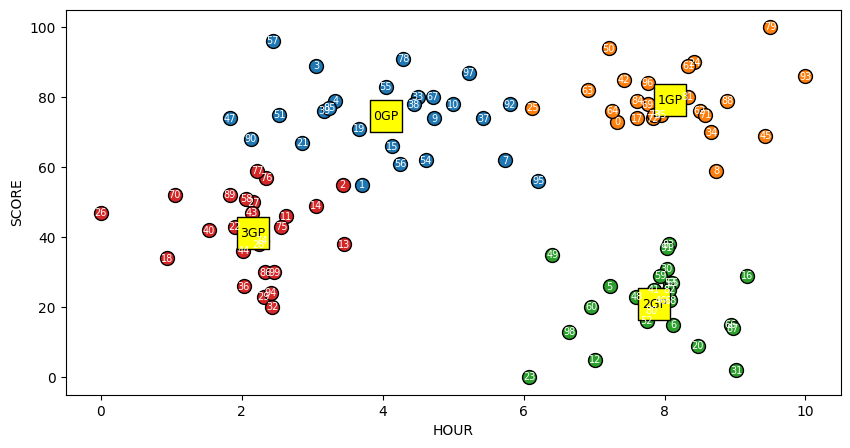

In [ ]:
K=4
model,X_org,X_trans,center_org=model_kmeans(K)
y_pred=model.fit_predict(X_trans)

plt.figure(figsize=(10,5))
for i in range(K):
    index=np.where(y_pred==i)
    x=X_org[index,0] # 0: 공부시간, 1: 점수
    y=X_org[index,1]
    plt.scatter(x,y,s=100,ec='black')
    cx=center_org[i,0]
    cy=center_org[i,1]
    plt.scatter(cx, cy, c='yellow',s=500, ec='black',marker='s')
    plt.text(cx, cy, f'{i}GP',ha='center',va='center',size=9)
    plt.xlabel('HOUR')
    plt.ylabel('SCORE')
for idx,x in enumerate(X_org):
    plt.text(x[0],x[1],idx ,ha='center', va='center', color='white',size=7)
plt.show()



In [ ]:
import pandas as pd
df_stu=pd.read_csv('data/학사관리/학생.csv')
df_pro=pd.read_csv('data/학사관리/교수.csv')

In [ ]:
stu=list(df_stu['학생이름']) #df_stu의 학생이름을 리스트화하여 stu로 정의
pro=list(df_pro['교수이름']) #df_pro의 교수이름을 리스트화하여 pro로 정의
names=stu+pro #stu,pro를 리스트화하여 가능
len(names) #이름을 개수
print(names) #학생 교수 이름을 나열

['서연우', '김창덕', '이지행', '김형명', '이원구', '이재영', '박혜경', '김수정', '홍길동', '이병렬', '이재광', '강승일', '오문환']


In [ ]:
df=pd.read_csv('data/KMeansData.csv')
# df.head()
df['name']=''#name 열을 만들고 공백으로 만듦(내용을 집어 넣을 수 있음)

In [ ]:
import random #랜덤하게 무언가를 넣어주는 라이브러리
idx=random.randint(0,len(names)-1)
idx, names[idx] #실행할때매다 random한 int가 발생함

(3, '김형명')

In [ ]:
#랜덤값을 발생시켜서 name에 넣어준다
for i in range(len(df)):
    import random
    idx=random.randint(0,len(names)-1)
    df.loc[i,'name']=names[idx] #df의 i값의 'name'열에 names의 idx(랜덤)의 내역을 넣어줌
df.tail(5)

,hour,score,name
95,6.21,56,김수정
96,7.76,84,김수정
97,5.22,87,강승일
98,6.65,13,이병렬
99,2.46,30,김수정


In [ ]:
#예측하기
kmeans, X, X_trans, centers_org=model_kmeans(5)
y_pred=kmeans.fit_predict(X_trans)
y_pred
df['cluster']=y_pred
df.tail()

,hour,score,name,cluster
95,6.21,56,김수정,0
96,7.76,84,김수정,1
97,5.22,87,강승일,0
98,6.65,13,이병렬,2
99,2.46,30,김수정,3


In [ ]:
for i in range(4):
    filt=df['cluster']==i #1번 그룹 학생들만 출력함
    df2=df[filt]
    print(f'{i}그룹-------------------------------')
    index=df2.index
    count=0
    for idx in index:
        print(f'{idx}:{df.loc[idx,"name"]}',end='')
        count+=1
        if count%10==0: print()
    print()


0그룹-------------------------------
7:김창덕9:이재영10:서연우15:박혜경25:오문환33:이재광37:김창덕38:이지행54:이재광55:이재광
56:김창덕67:이재영78:이원구92:박혜경95:김수정97:강승일
1그룹-------------------------------
0:홍길동8:이병렬17:김형명24:김창덕34:김창덕35:박혜경42:강승일45:이지행50:박혜경61:이재영
62:홍길동63:이병렬64:이지행69:이재영71:김형명72:김창덕73:이재영79:김수정81:이원구84:오문환
88:김창덕93:김수정96:김수정
2그룹-------------------------------
5:이재광6:서연우12:김수정16:홍길동20:박혜경23:김창덕30:김창덕31:김형명41:오문환46:홍길동
48:김형명49:오문환52:강승일53:이재광59:박혜경60:이지행65:서연우66:오문환68:이재영80:강승일
82:이재영83:오문환87:서연우91:홍길동98:이병렬
3그룹-------------------------------
2:이병렬11:김형명13:서연우14:김형명18:김형명22:김창덕26:김창덕27:서연우28:이재광29:이병렬
32:이원구36:이재영40:이재영43:이원구44:김수정58:서연우70:이지행74:김수정75:서연우76:오문환
86:서연우89:이병렬94:서연우99:김수정
